Saving processed_dataset_with_voltage_full.csv to processed_dataset_with_voltage_full.csv


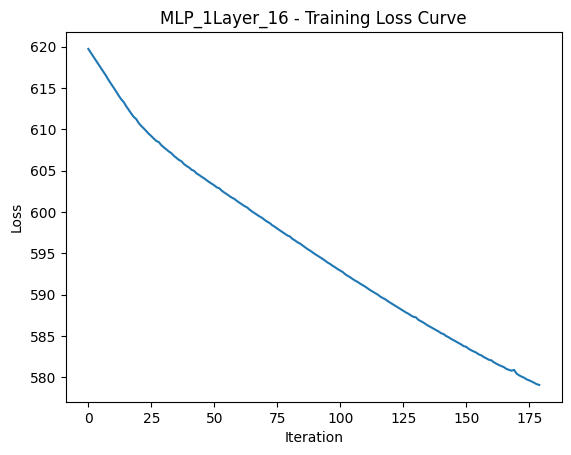

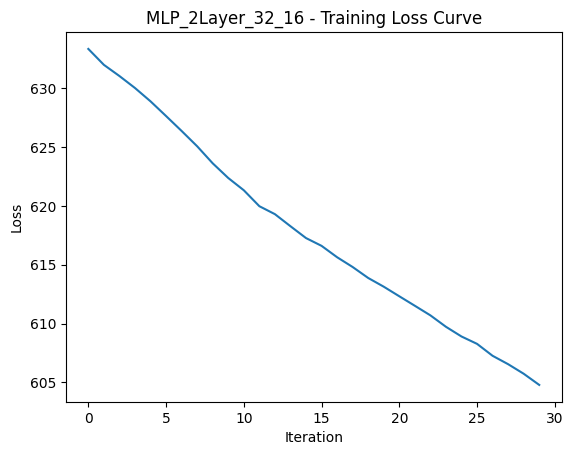

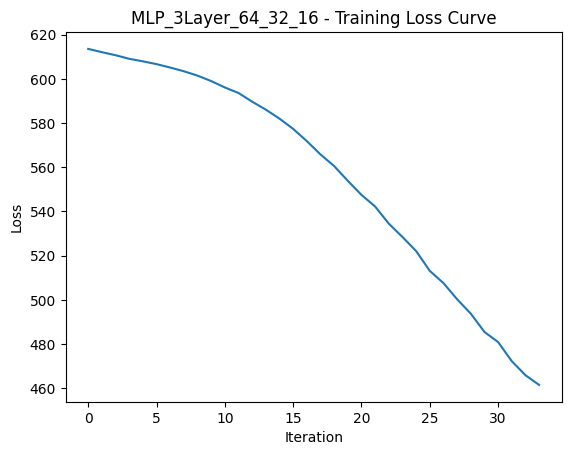

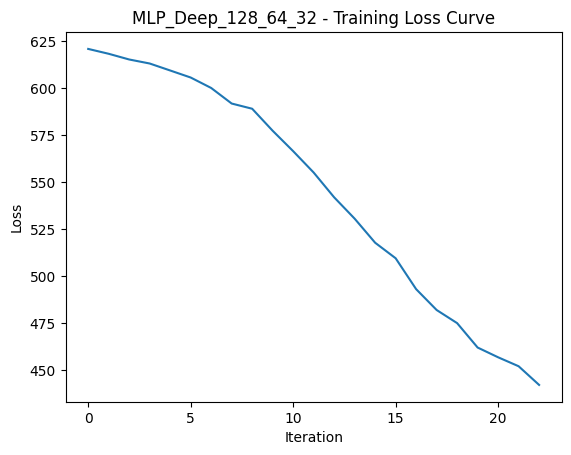


Model Comparison:

                     Train R2   Test R2  Test RMSE
MLP_1Layer_16        0.054710 -0.876051   3.698666
MLP_2Layer_32_16     0.013594  0.100030   2.561750
MLP_3Layer_64_32_16  0.135695 -0.893133   3.715467
MLP_Deep_128_64_32   0.113646 -0.479824   3.284943

Overfitting Analysis:
MLP_1Layer_16: ⚠ Overfitting Detected
MLP_2Layer_32_16: ✅ Good Generalization
MLP_3Layer_64_32_16: ⚠ Overfitting Detected
MLP_Deep_128_64_32: ⚠ Overfitting Detected

Best Model: MLP_2Layer_32_16


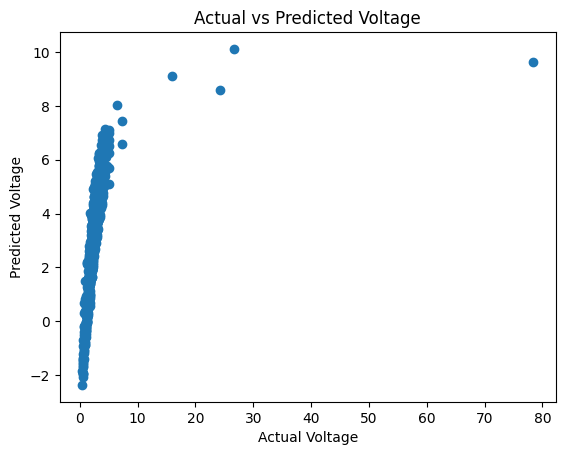

In [2]:
# ==============================
# 1️⃣ IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
from google.colab import files
uploaded = files.upload()
# ==============================
# 2️⃣ LOAD DATASET
# ==============================
df = pd.read_csv("/content/processed_dataset_with_voltage_full.csv")

# Remove infinite / NaN values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# ==============================
# 3️⃣ ENCODE GENDER
# ==============================
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

# ==============================
# 4️⃣ FEATURES & TARGET
# ==============================
X = df[['age', 'gender', 'bmi', 'glucose']]
y = df['voltage']

# ==============================
# 5️⃣ TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ==============================
# 6️⃣ FEATURE SCALING
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 7️⃣ DEFINE MULTIPLE MLP MODELS
# ==============================
models = {
    "MLP_1Layer_16": (16,),
    "MLP_2Layer_32_16": (32,16),
    "MLP_3Layer_64_32_16": (64,32,16),
    "MLP_Deep_128_64_32": (128,64,32)
}

results = {}

# ==============================
# 8️⃣ TRAIN MODELS
# ==============================
for name, architecture in models.items():

    mlp = MLPRegressor(
        hidden_layer_sizes=architecture,
        activation='relu',
        solver='adam',
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.2,
        random_state=42
    )

    mlp.fit(X_train, y_train)

    # Predictions
    y_train_pred = mlp.predict(X_train)
    y_test_pred = mlp.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    results[name] = [train_r2, test_r2, rmse]

    # ==============================
    # Plot Loss Curve
    # ==============================
    plt.figure()
    plt.plot(mlp.loss_curve_)
    plt.title(f"{name} - Training Loss Curve")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.show()

# ==============================
# 9️⃣ DISPLAY RESULTS
# ==============================
results_df = pd.DataFrame(results,
                          index=["Train R2", "Test R2", "Test RMSE"]).T

print("\nModel Comparison:\n")
print(results_df)

# ==============================
# 🔟 OVERFITTING CHECK
# ==============================
print("\nOverfitting Analysis:")
for model in results_df.index:
    train_r2 = results_df.loc[model, "Train R2"]
    test_r2 = results_df.loc[model, "Test R2"]

    if train_r2 - test_r2 > 0.05:
        print(f"{model}: ⚠ Overfitting Detected")
    else:
        print(f"{model}: ✅ Good Generalization")

# ==============================
# 1️⃣1️⃣ PREDICTION VS ACTUAL PLOT
# ==============================
best_model_name = results_df["Test R2"].idxmax()
print(f"\nBest Model: {best_model_name}")

best_architecture = models[best_model_name]
best_mlp = MLPRegressor(
    hidden_layer_sizes=best_architecture,
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.2,
    random_state=42
)
best_mlp.fit(X_train, y_train)

y_pred = best_mlp.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Voltage")
plt.ylabel("Predicted Voltage")
plt.title("Actual vs Predicted Voltage")
plt.show()